In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

The "Baseball Player Metrics" dataset comprises comprehensive statistical records for a diverse range of baseball players. It encompasses essential performance metrics 

In [2]:
df = pd.read_csv("500hits.csv", encoding="latin-1")
# latin 1 coz of 'utf-8' codec can't decode byte 0xe1 in position 11379: invalid continuation byte

In [3]:
df.head(5)

,PLAYER,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA,HOF
0,Ty Cobb,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,178,0.366,1
1,Stan Musial,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,31,0.331,1
2,Tris Speaker,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,129,0.345,1
3,Derek Jeter,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,97,0.310,1
4,Honus Wagner,21,2792,10430,1736,3430,640,252,101,0,963,327,722,15,0.329,1


Player: The name of the baseball player.

YRS: The number of years the player has been active in professional baseball.

G: The total number of games played by the player.

AB: The total number of at-bats (plate appearances) by the player.

R: The total number of runs scored by the player.

H: The total number of hits recorded by the player.

2B: The total number of doubles hit by the player.

3B: The total number of triples hit by the player.

HR: The total number of home runs hit by the player.

RBI: The total number of runs batted in (RBIs) by the player.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PLAYER  465 non-null    object 
 1   YRS     465 non-null    int64  
 2   G       465 non-null    int64  
 3   AB      465 non-null    int64  
 4   R       465 non-null    int64  
 5   H       465 non-null    int64  
 6   2B      465 non-null    int64  
 7   3B      465 non-null    int64  
 8   HR      465 non-null    int64  
 9   RBI     465 non-null    int64  
 10  BB      465 non-null    int64  
 11  SO      465 non-null    int64  
 12  SB      465 non-null    int64  
 13  CS      465 non-null    int64  
 14  BA      465 non-null    float64
 15  HOF     465 non-null    int64  
dtypes: float64(1), int64(14), object(1)
memory usage: 58.2+ KB


drop column that we believe isn't helpful for predicting. drop PLAYER as it's just a name name shouldn't be predictor if the baseball player should make the hall of fame 

In [5]:
X = df.drop(columns=["PLAYER", "HOF"])

we do not want our target in the feature dataset so for X dropping the PLAYER and HOF columns 
We set y = the target we want to predict which is if a player makes the hall of fame 

In [6]:
y = df["HOF"]

In [7]:
X.head()

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA
0,24,3035,11434,2246,4189,724,295,117,726,1249,357,892,178,0.366
1,22,3026,10972,1949,3630,725,177,475,1951,1599,696,78,31,0.331
2,22,2789,10195,1882,3514,792,222,117,724,1381,220,432,129,0.345
3,20,2747,11195,1923,3465,544,66,260,1311,1082,1840,358,97,0.310
4,21,2792,10430,1736,3430,640,252,101,0,963,327,722,15,0.329


In [8]:
X.shape

(465, 14)

In [9]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: HOF, dtype: int64

In [10]:
y.shape

(465,)

80% training with 20% test split 

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.2
)

In [12]:
X_train.shape

(372, 14)

In [13]:
X_test.shape

(93, 14)

In [14]:
y_train.shape

(372,)

In [15]:
y_test.shape

(93,)

In [16]:
X_train.describe()

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA
count,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000
mean,17.010753,2048.526882,7514.346774,1147.586022,2168.067204,381.255376,77.854839,197.887097,877.158602,780.892473,834.672043,195.032258,56.645161,0.288444
std,2.836020,359.608872,1293.124126,291.286912,414.856385,95.678746,47.958095,144.515151,493.051874,327.974695,486.213119,180.102903,46.660244,0.020682
min,11.000000,1331.000000,5472.000000,601.000000,1660.000000,177.000000,8.000000,14.000000,0.000000,239.000000,0.000000,8.000000,0.000000,0.246000
25%,15.000000,1798.750000,6531.500000,933.250000,1841.000000,313.000000,40.000000,75.000000,613.250000,527.000000,431.750000,59.750000,21.750000,0.273000
50%,17.000000,1988.000000,7221.000000,1099.000000,2076.500000,366.000000,66.500000,170.000000,963.000000,725.000000,787.000000,140.500000,51.000000,0.287000
75%,19.000000,2257.500000,8184.250000,1299.250000,2354.500000,436.250000,108.000000,291.000000,1207.250000,952.750000,1197.250000,285.000000,84.000000,0.299250
max,26.000000,3308.000000,12364.000000,2295.000000,3771.000000,792.000000,252.000000,755.000000,2297.000000,2190.000000,2597.000000,1406.000000,335.000000,0.358000


In [17]:
X_test.describe()

,YRS,G,AB,R,H,2B,3B,HR,RBI,BB,SO,SB,CS,BA
count,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000,93.000000
mean,17.204301,2049.387097,7499.892473,1161.225806,2178.967742,379.741935,81.354839,213.698925,962.666667,794.236559,898.666667,199.397849,63.838710,0.289785
std,2.469638,334.569387,1304.786068,284.218575,461.931730,100.159753,54.814836,140.044541,453.825175,326.800478,500.474456,189.619020,53.027739,0.023282
min,11.000000,1332.000000,4981.000000,667.000000,1666.000000,186.000000,3.000000,9.000000,0.000000,311.000000,15.000000,7.000000,0.000000,0.249000
25%,16.000000,1823.000000,6503.000000,961.000000,1804.000000,308.000000,45.000000,97.000000,779.000000,553.000000,478.000000,83.000000,27.000000,0.273000
50%,17.000000,2002.000000,7297.000000,1117.000000,2055.000000,371.000000,71.000000,206.000000,976.000000,760.000000,852.000000,128.000000,58.000000,0.287000
75%,19.000000,2215.000000,8136.000000,1284.000000,2416.000000,436.000000,97.000000,299.000000,1183.000000,965.000000,1278.000000,251.000000,90.000000,0.303000
max,24.000000,3035.000000,11434.000000,2246.000000,4189.000000,724.000000,309.000000,548.000000,1922.000000,2019.000000,1916.000000,938.000000,307.000000,0.366000


In [ ]:
Dummy = DummyClassifier(strategy="most_frequent")
Dummy.fit(X_train, y_train)
score = Dummy.score(X_test, y_test)
print(f"Accuracy Score: {score * 100:.2f}")

Accuracy Score: 66.67


In [20]:
y_pred = Dummy.predict(X_test)

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
'''

[[62  0]
 [31  0]]
              precision    recall  f1-score   support

           0       0.67      1.00      0.80        62
           1       0.00      0.00      0.00        31

    accuracy                           0.67        93
   macro avg       0.33      0.50      0.40        93
weighted avg       0.44      0.67      0.53        93

'''

In [23]:
y.value_counts()

HOF
0    313
1    151
2      1
Name: count, dtype: int64

In [24]:
y_test.value_counts()

HOF
0    62
1    31
Name: count, dtype: int64

In [25]:
print("Full distribution:")
print(y.value_counts().sort_index())

print("\nRow with HOF=2:")
print(df[df["HOF"] == 2][["PLAYER", "HOF"]])

Full distribution:
HOF
0    313
1    151
2      1
Name: count, dtype: int64

Row with HOF=2:
             PLAYER  HOF
160  Tim Raines Sr.    2


Text(0.5, 1.0, 'Confusion Matrix Heatmap')

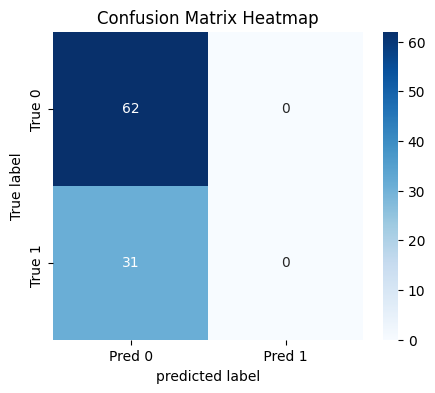

In [27]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=["Pred 0", " Pred 1 "],
    yticklabels=["True 0", "True 1 "],
)
plt.xlabel("predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix Heatmap")

##### The test set contains 62 players labeled as ***HOF=0*** and 31 players labeled as ***HOF=1*** they're imbalanced 2:1 

##### Confusion matrix findings 
- Confusion matrix = [62,0] , [31,0]
- True Negative (0 correctly predicted as 0) = **62**
- False Negative (1 predicted as 0) = **31**
- True Positive ( 1 correctly predicted as 1) = **0** 
- False Positive (0 predicted as 1) = **0**